In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange


import matplotlib as mpl
import os
import sys
import math
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. concatenated records

#### 1.1 records before GDPR

In [2]:
df_pre = pd.read_csv("pregdprApril2016_SAP.csv")
df_pre.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,1.228504e+09,66.71,10.0,1.0,1.612828,1.228504e+09,66.85,10.0,1.0,1.612828,...,67.45,10.0,1.0,1.612828,1.228504e+09,68.55,10.0,1.0,1.612828,66.085530
1,1.228504e+09,66.85,10.0,1.0,1.612828,1.228504e+09,67.35,10.0,1.0,1.612828,...,68.55,10.0,1.0,1.612828,1.228504e+09,68.88,10.0,1.0,1.612828,66.024003
2,1.228504e+09,67.35,10.0,1.0,1.612828,1.228504e+09,67.45,10.0,1.0,1.612828,...,68.88,10.0,1.0,1.612828,1.228504e+09,68.48,10.0,1.0,1.612828,65.523810
3,1.228504e+09,67.45,10.0,1.0,1.612828,1.228504e+09,68.55,10.0,1.0,1.612828,...,68.48,10.0,1.0,1.612828,1.228504e+09,68.41,10.0,1.0,1.612828,64.978919
4,1.228504e+09,68.55,10.0,1.0,1.612828,1.228504e+09,68.88,10.0,1.0,1.612828,...,68.41,10.0,1.0,1.612828,1.228504e+09,67.63,10.0,1.0,1.612828,64.858517


In [3]:
X_pre = df_pre.iloc[:, : -1].values
X_pre, X_pre.shape, type(X_pre)

(array([[1.22850423e+09, 6.67100000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.61282792e+00],
        [1.22850423e+09, 6.68500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.61282792e+00],
        [1.22850423e+09, 6.73500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.61282792e+00],
        ...,
        [1.22850423e+09, 7.01900000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.63880319e+00],
        [1.22850423e+09, 7.00000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.63880319e+00],
        [1.22850423e+09, 7.00500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.63880319e+00]]),
 (266, 25),
 numpy.ndarray)

In [4]:
y_pre = df_pre["target"].values
y_pre, y_pre.shape, type(y_pre)

(array([66.08552986, 66.02400259, 65.52381043, 64.97891933, 64.85851659,
        65.08041481, 66.39941176, 66.52961664, 66.41532729, 66.46431366,
        67.3312408 , 67.26278016, 67.53790499, 67.11260662, 67.47639197,
        66.54376014, 66.40160492, 67.46493412, 66.3874701 , 66.30565069,
        66.16271304, 66.19772967, 66.7670997 , 66.80709191, 66.96967257,
        66.98951488, 66.74709935, 65.53716775, 65.25461764, 65.19349825,
        65.17579994, 65.42245265, 65.81548436, 65.90111845, 66.15667473,
        66.4261275 , 66.41807622, 66.34976403, 66.18432227, 65.67399174,
        64.97925131, 65.308119  , 65.27047996, 65.06119805, 65.06346346,
        64.97439307, 64.46585424, 64.17765314, 64.97574731, 64.5733338 ,
        64.10604203, 64.27322182, 63.89103317, 63.4624108 , 63.28914047,
        63.45109591, 62.7973311 , 62.60450176, 62.34574785, 62.89651288,
        63.90656356, 63.93264371, 63.7892241 , 63.90648111, 63.87154091,
        64.21672888, 64.75320899, 64.45652724, 64.6

#### 1.2 records after GDPR

In [5]:
df_post = pd.read_csv("postgdprMay2018_SAP.csv")
df_post.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,1.228504e+09,96.67,10.0,1.0,1.713145,1.228504e+09,97.45,10.0,1.0,1.713145,...,98.99,10.0,1.0,1.713145,1.228504e+09,98.53,10.0,1.0,1.713145,75.730632
1,1.228504e+09,97.45,10.0,1.0,1.713145,1.228504e+09,98.27,10.0,1.0,1.713145,...,98.53,10.0,1.0,1.713145,1.228504e+09,100.50,10.0,1.0,1.713145,76.018620
2,1.228504e+09,98.27,10.0,1.0,1.713145,1.228504e+09,98.99,10.0,1.0,1.713145,...,100.50,10.0,1.0,1.713145,1.228504e+09,101.76,10.0,1.0,1.713145,76.491443
3,1.228504e+09,98.99,10.0,1.0,1.713145,1.228504e+09,98.53,10.0,1.0,1.713145,...,101.76,10.0,1.0,1.713145,1.228504e+09,102.04,10.0,1.0,1.713145,76.561307
4,1.228504e+09,98.53,10.0,1.0,1.713145,1.228504e+09,100.50,10.0,1.0,1.713145,...,102.04,10.0,1.0,1.713145,1.228504e+09,101.56,10.0,1.0,1.713145,76.891882


In [6]:
X_post = df_post.iloc[:, : -1].values
X_post, X_post.shape, type(X_post)

(array([[1.22850423e+09, 9.66700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.71314544e+00],
        [1.22850423e+09, 9.74500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.71314544e+00],
        [1.22850423e+09, 9.82700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.71314544e+00],
        ...,
        [1.22850423e+09, 1.22380000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.73528291e+00],
        [1.22850423e+09, 1.23880000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.73528291e+00],
        [1.22850423e+09, 1.20520000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.73528291e+00]]),
 (391, 25),
 numpy.ndarray)

In [7]:
y_post = df_post["target"].values
y_post, y_post.shape, type(y_post)

(array([75.73063167, 76.01861953, 76.49144298, 76.56130666, 76.89188159,
        76.50559608, 76.24631414, 76.70225713, 76.26171736, 74.75674616,
        74.67863998, 74.57820785, 74.99770115, 73.32131488, 74.01094114,
        73.98309992, 73.84406976, 72.71632801, 73.47162817, 73.52595976,
        74.51784072, 74.84394298, 74.58620967, 74.93523352, 75.41302153,
        75.64146198, 76.37616134, 76.42493476, 73.72329445, 72.97953973,
        72.73967024, 73.00661722, 73.21271031, 74.04734564, 73.64920232,
        71.75548617, 71.17942476, 71.26364392, 71.59069225, 71.64739331,
        71.74774942, 70.95523697, 71.82931805, 71.86111851, 71.45689302,
        72.73803562, 72.78405438, 72.90640599, 74.63592742, 74.60562397,
        74.64046976, 74.30060526, 74.51675278, 75.35877002, 75.68042732,
        75.87656395, 75.83518376, 75.63462718, 75.69476146, 75.86902077,
        75.69585278, 75.2990806 , 73.7222115 , 73.8929027 , 75.13060441,
        75.85118618, 76.50976746, 77.00546812, 76.6

### 2. BNN and plot functions

In [8]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [9]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("normalized closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [10]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of normalized closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. uncertainty quantification of data pre GDPR

#### 3.1 Train the prior of BNN.

In [11]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 1000  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre, y_pre)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200),
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=0, gpu_gp=False)
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.log(torch.exp(t) - 1, out=out)
/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/models/model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH().
This transform will produce

>>> Iteration #   1: Wasserstein Dist 8.1276
>>> Iteration #  10: Wasserstein Dist 2.4239
>>> Iteration #  20: Wasserstein Dist 1.3850
>>> Iteration #  30: Wasserstein Dist 2.4808
>>> Iteration #  40: Wasserstein Dist 2.2611
>>> Iteration #  50: Wasserstein Dist 0.6953
>>> Iteration #  60: Wasserstein Dist -0.2534
>>> Iteration #  70: Wasserstein Dist 0.4865
>>> Iteration #  80: Wasserstein Dist -0.9154
>>> Iteration #  90: Wasserstein Dist 0.9415
>>> Iteration # 100: Wasserstein Dist 0.3275
>>> Iteration # 110: Wasserstein Dist 0.6958
>>> Iteration # 120: Wasserstein Dist -0.0884
>>> Iteration # 130: Wasserstein Dist 0.8325
>>> Iteration # 140: Wasserstein Dist -0.8735
>>> Iteration # 150: Wasserstein Dist 0.0684
>>> Iteration # 160: Wasserstein Dist 0.8889
>>> Iteration # 170: Wasserstein Dist 2.8027
>>> Iteration # 180: Wasserstein Dist 0.8784
>>> Iteration # 190: Wasserstein Dist 0.2674
>>> Iteration # 200: Wasserstein Dist 0.9283
>>> Iteration # 210: Wasserstein Dist -1.1483
>>> I

In [12]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([4.3618], requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([3.7432], requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.3298], requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-1.8868], requires_grad=True)


In [13]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(4.3618), maintain_positivity(1.3298)]
pre_bias_prior = [maintain_positivity(3.7432), maintain_positivity(-1.8868)]

#### 3.2 train the BNN

In [14]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [15]:
num_epochs = 25000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

  0%|          | 2/25000 [00:00<1:25:30,  4.87it/s, loss=20381.955]

[iteration 0001] loss: 17651.937


 20%|██        | 5002/25000 [15:04<59:56,  5.56it/s, loss=158.022]    

[iteration 5001] loss: 281.206


 40%|████      | 10002/25000 [29:27<41:37,  6.00it/s, loss=29.230]   

...

 60%|██████    | 15002/25000 [43:47<27:36,  6.04it/s, loss=24.034] 

[iteration 15001] loss: 27.727


 80%|████████  | 20002/25000 [57:59<13:30,  6.17it/s, loss=17.561]

[iteration 20001] loss: 18.621


100%|██████████| 25000/25000 [1:12:09<00:00,  5.77it/s, loss=13.440]


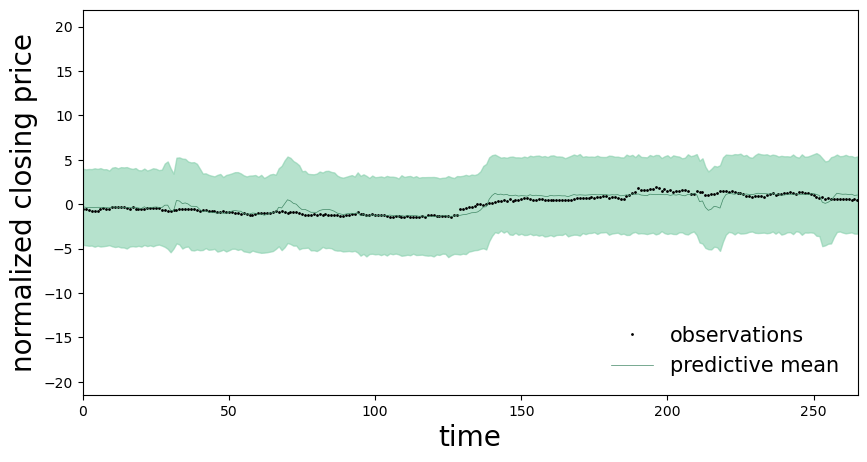

In [16]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

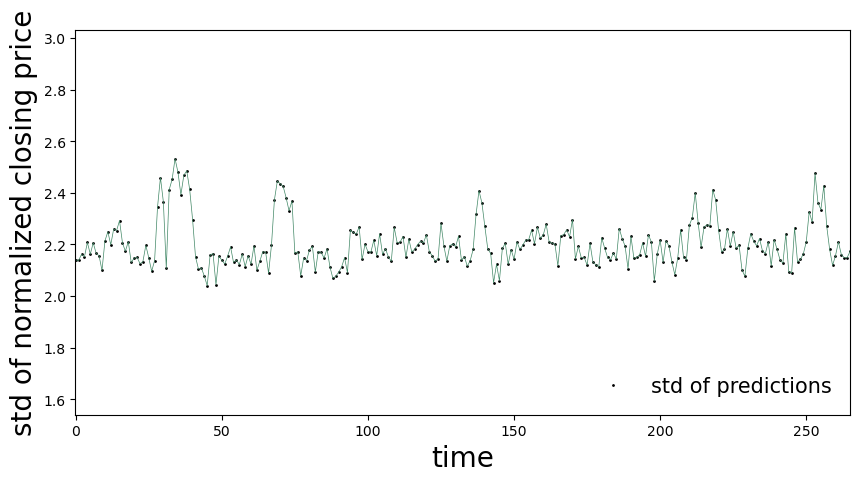

In [17]:
plot_uncertainty(preds, y_pre_n)

### 4. uncertainty quantification of data post GDPR

#### 4.1 Train the prior of BNN.

In [18]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 1000  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post, y_post)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200),
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=0, gpu_gp=False)
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 7.1121
>>> Iteration #  10: Wasserstein Dist 0.2675
>>> Iteration #  20: Wasserstein Dist 1.4091
>>> Iteration #  30: Wasserstein Dist 0.6103
>>> Iteration #  40: Wasserstein Dist -2.0788
>>> Iteration #  50: Wasserstein Dist 0.8523
>>> Iteration #  60: Wasserstein Dist 3.6947
>>> Iteration #  70: Wasserstein Dist 1.5015
>>> Iteration #  80: Wasserstein Dist -0.1799
>>> Iteration #  90: Wasserstein Dist -0.0722
>>> Iteration # 100: Wasserstein Dist 0.2051
>>> Iteration # 110: Wasserstein Dist 0.5986
>>> Iteration # 120: Wasserstein Dist 2.0603
>>> Iteration # 130: Wasserstein Dist 1.3352
>>> Iteration # 140: Wasserstein Dist 0.4748
>>> Iteration # 150: Wasserstein Dist 0.1701
>>> Iteration # 160: Wasserstein Dist 1.0342
>>> Iteration # 170: Wasserstein Dist 0.4752
>>> Iteration # 180: Wasserstein Dist 1.0294
>>> Iteration # 190: Wasserstein Dist -0.7450
>>> Iteration # 200: Wasserstein Dist 0.3586
>>> Iteration # 210: Wasserstein Dist -0.2428
>>> I

In [19]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.3158], requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.6837], requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.2595], requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.5858], requires_grad=True)


In [20]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.3158), maintain_positivity(1.2595)]
post_bias_prior = [maintain_positivity(2.6837), maintain_positivity(-0.5858)]

#### 4.2 train the BNN

In [21]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [22]:
num_epochs = 25000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 2/25000 [00:00<1:39:00,  4.21it/s, loss=6222.461]

[iteration 0001] loss: 4834.097


 20%|██        | 5002/25000 [15:05<1:03:32,  5.25it/s, loss=77.426]   

[iteration 5001] loss: 112.831


 40%|████      | 10002/25000 [29:49<43:24,  5.76it/s, loss=33.396]   

...

 60%|██████    | 15002/25000 [44:25<28:47,  5.79it/s, loss=15.163] 

[iteration 15001] loss: 15.585


 80%|████████  | 20002/25000 [59:09<14:58,  5.56it/s, loss=12.093]

[iteration 20001] loss: 11.793


100%|██████████| 25000/25000 [1:13:54<00:00,  5.64it/s, loss=9.964] 


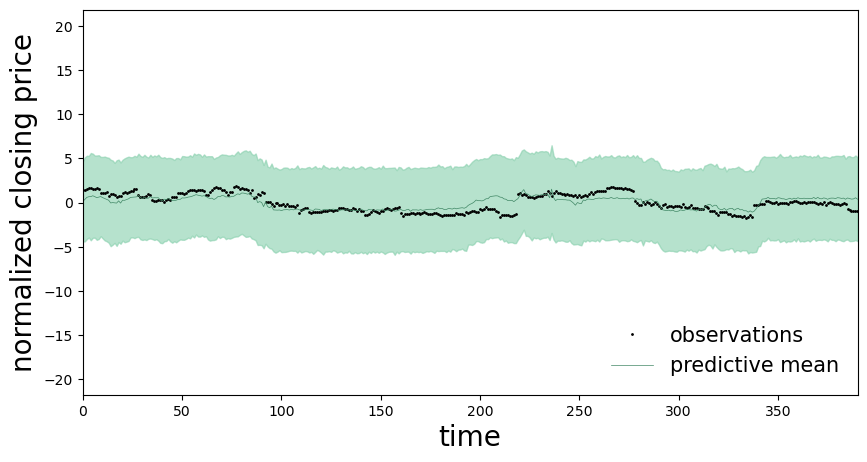

In [23]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_post_n_tensor)

plot_predictions(preds, y_post_n_tensor)

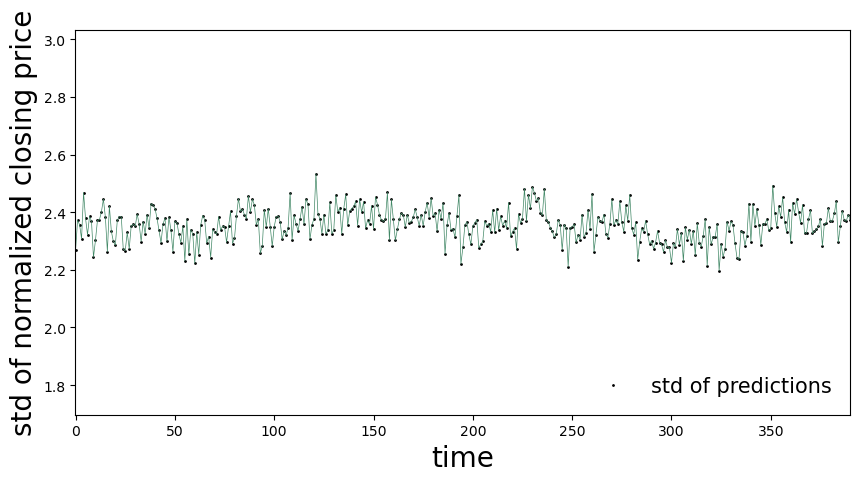

In [24]:
plot_uncertainty(preds, y_post_n)